# UR5 – Cinemática Direta com Python + CoppeliaSim
### ENGA73 – Sistemas Robóticos | UFBA 2026/1


---
## Parâmetros DH do UR5

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

# Parâmetros DH do UR5
D1, D4, D5, D6 = 0.089159, 0.10915, 0.09465, 0.08230
A2, A3         = -0.425, -0.39225

DH = [
    [np.pi/2,    0,    D1],   # α1,  a1=0
    [0,         A2,     0],   # α2,  a2
    [0,         A3,     0],   # α3,  a3
    [np.pi/2,    0,    D4],   # α4,  a4=0
    [-np.pi/2,   0,    D5],   # α5,  a5=0
    [0,          0,    D6],   # α6,  a6=0
]

print("Parâmetros DH do UR5:")
for i, (alpha, a, d) in enumerate(DH):
    print(f"  Joint {i+1}: α={alpha}, a={a}, d={d}")

Parâmetros DH do UR5:
  Joint 1: α=1.5707963267948966, a=0, d=0.089159
  Joint 2: α=0, a=-0.425, d=0
  Joint 3: α=0, a=-0.39225, d=0
  Joint 4: α=1.5707963267948966, a=0, d=0.10915
  Joint 5: α=-1.5707963267948966, a=0, d=0.09465
  Joint 6: α=0, a=0, d=0.0823


## Funções de Cinemática Direta

In [2]:
def dh_transform(alpha, a, d, theta):
    # Transformação DH T = Rz(θᵢ) · Tz(dᵢ) · Tx(aᵢ) · Rx(αᵢ)
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)
    return np.array([
        [ct,   -st*ca,   st*sa,   a*ct],
        [st,    ct*ca,  -ct*sa,   a*st],
        [0,      sa,      ca,      d  ],
        [0,       0,       0,      1  ]
    ])

def fk(thetas_deg):
    # Cinemática Direta completa. Retorna T (4x4) e cadeia de frames.
    thetas = np.radians(thetas_deg)
    T = np.eye(4)
    chain = [T.copy()]
    for i, (alpha, a, d) in enumerate(DH):
        T = T @ dh_transform(alpha, a, d, thetas[i])
        chain.append(T.copy())
    return T, chain


---
## Conexão com o CoppeliaSim



In [4]:
import sim          # sim.py precisa estar na mesma pasta
import simConst     # simConst.py também

# Fecha qualquer conexão anterior
sim.simxFinish(-1)

# Conecta ao servidor (CoppeliaSim deve estar rodando com a cena aberta)
clientID = sim.simxStart(
    '127.0.0.1',   # endereço (local)
    19999,         # porta padrão da Legacy API
    True,          # waitUntilConnected
    True,          # doNotReconnectOnceDisconnected
    5000,          # timeout [ms]
    5              # commThreadCycleInMs
)

if clientID > -1:
    print(f"Conectado ao CoppeliaSim! (clientID = {clientID})")
else:
    raise ConnectionError(
        "Não foi possível conectar.\n"
        "Verifique: 1) CoppeliaSim está aberto?  "
        "2) Simulação está em Play (▶)?  "
        "3) sim.py e remoteApi estão na mesma pasta?"
    )

Conectado ao CoppeliaSim! (clientID = 0)


## 4. Obtendo handles das juntas e do end-effector

In [5]:
mode = sim.simx_opmode_blocking

JOINT_NAMES = [
    'UR5_joint1', 'UR5_joint2', 'UR5_joint3',
    'UR5_joint4', 'UR5_joint5', 'UR5_joint6'
]

# Handles das juntas
joint_handles = []
for name in JOINT_NAMES:
    ret, handle = sim.simxGetObjectHandle(clientID, name, mode)
    status = "✅" if ret == 0 else "❌"
    print(f"  {status} {name}: handle={handle}  (ret={ret})")
    joint_handles.append(handle)

# Handle da base
ret_base, base_handle = sim.simxGetObjectHandle(clientID, 'UR5', mode)
print(f"\n  {'✅' if ret_base==0 else '❌'} Base 'UR5': handle={base_handle}  (ret={ret_base})")

# Handle do end-effector
ret_ee, ee_handle = sim.simxGetObjectHandle(clientID, 'UR5_connection', mode)
print(f"  {'✅' if ret_ee==0 else '❌'} EE 'UR5_connection': handle={ee_handle}  (ret={ret_ee})")

  ✅ UR5_joint1: handle=31  (ret=0)
  ✅ UR5_joint2: handle=34  (ret=0)
  ✅ UR5_joint3: handle=37  (ret=0)
  ✅ UR5_joint4: handle=40  (ret=0)
  ✅ UR5_joint5: handle=43  (ret=0)
  ✅ UR5_joint6: handle=45  (ret=0)

  ✅ Base 'UR5': handle=29  (ret=0)
  ✅ EE 'UR5_connection': handle=48  (ret=0)


## 5. Funções de controle e leitura

In [6]:
def set_joint_positions(thetas_deg):
    """Envia posições alvo para as 6 juntas (em graus)."""
    for handle, angle in zip(joint_handles, thetas_deg):
        sim.simxSetJointTargetPosition(
            clientID, handle, np.radians(angle),
            sim.simx_opmode_oneshot
        )

def read_joint_positions():
    """Lê os ângulos atuais das juntas. Retorna array em graus."""
    angles = []
    for handle in joint_handles:
        _, angle = sim.simxGetJointPosition(clientID, handle, sim.simx_opmode_blocking)
        angles.append(np.degrees(angle))
    return np.array(angles)

def read_ee_pose():
    """Lê posição [x,y,z] e orientação Euler [α,β,γ] do end-effector."""
    _, pos = sim.simxGetObjectPosition(
        clientID, ee_handle, -1, sim.simx_opmode_blocking)
    _, euler = sim.simxGetObjectOrientation(
        clientID, ee_handle, -1, sim.simx_opmode_blocking)
    return np.array(pos), np.degrees(euler)

print("Funções de controle definidas ✓")

Funções de controle definidas ✓


---
## 6. Validação da Cinemática Direta

Enviamos uma pose para o simulador, lemos o ground truth e comparamos com nossa FK.

In [7]:
import time

# ── Poses de teste ─────────────────────────────────────────────────────────
test_poses = [
    [  0,    0,    0,    0,    0,    0],   # zero
    [ 90,    0,   90,    0,  -90,    0],   # pose do script MATLAB original
    [ 30,  -45,   60,    0,   90,    0],   # pose arbitrária 1
    [-45,  -60,   45,   30,  -45,   90],   # pose arbitrária 2
]

results = []

for i, pose in enumerate(test_poses):
    # 1) Envia para o simulador
    set_joint_positions(pose)
    time.sleep(0.8)   # aguarda o robô mover

    # 2) Lê ground truth do simulador
    gt_pos, gt_euler = read_ee_pose()
    gt_joints = read_joint_positions()

    # 3) Calcula FK analítica
    T, _ = fk(pose)
    calc_pos = T[:3, 3]
    calc_rpy = rotation_to_rpy(T[:3, :3])

    # 4) Calcula erros
    pos_err = np.linalg.norm(calc_pos - gt_pos) * 1000   # mm
    # Nota: CoppeliaSim retorna Euler na convenção XYZ; ajuste se necessário
    rpy_err = np.abs(calc_rpy - gt_euler)

    results.append({
        'pose': pose,
        'calc_pos': calc_pos,
        'gt_pos': gt_pos,
        'pos_err_mm': pos_err,
        'calc_rpy': calc_rpy,
        'gt_euler': gt_euler,
        'rpy_err': rpy_err,
    })

    print(f"\nPose {i+1}: θ = {pose}")
    print(f"  FK calc.  : x={calc_pos[0]:.4f}  y={calc_pos[1]:.4f}  z={calc_pos[2]:.4f}")
    print(f"  Simulador : x={gt_pos[0]:.4f}  y={gt_pos[1]:.4f}  z={gt_pos[2]:.4f}")
    print(f"  Erro pos  : {pos_err:.3f} mm")
    print(f"  Erro RPY  : [{rpy_err[0]:.3f}°, {rpy_err[1]:.3f}°, {rpy_err[2]:.3f}°]")

print("\n✅ Validação concluída")

NameError: name 'rotation_to_rpy' is not defined

## 7. Gráficos de validação (erro de posição e orientação)

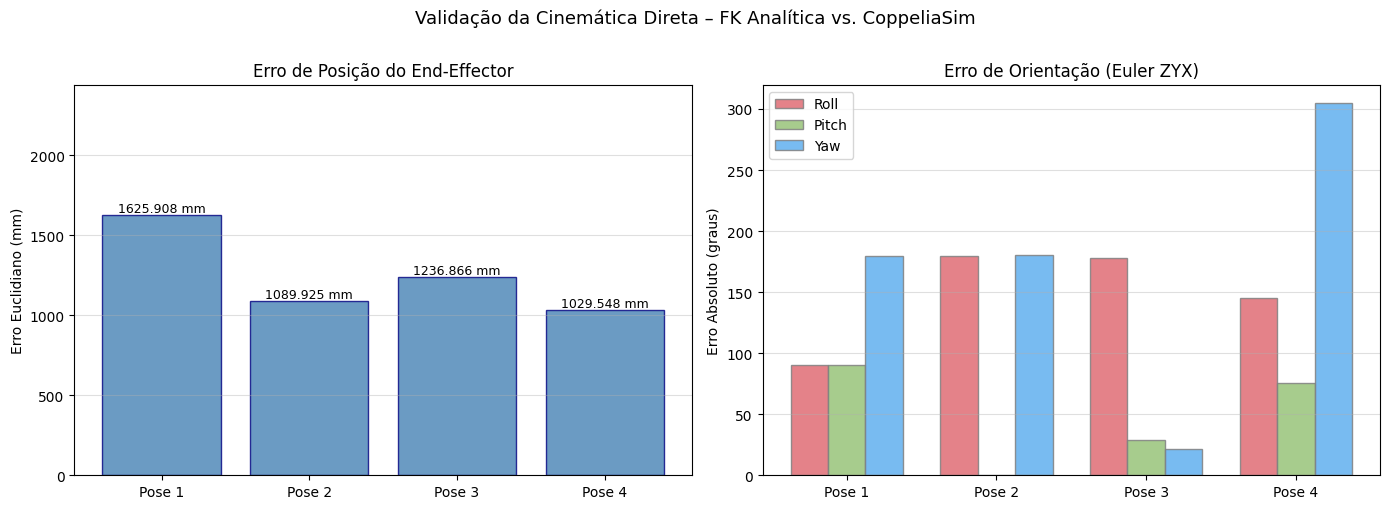

Gráfico salvo em validacao_fk.png


In [12]:
fig = plt.figure(figsize=(14, 5))
fig.suptitle('Validação da Cinemática Direta – FK Analítica vs. CoppeliaSim', fontsize=13, y=1.01)
gs = gridspec.GridSpec(1, 2, figure=fig)

n = len(results)
labels = [f"Pose {i+1}" for i in range(n)]
x = np.arange(n)

# ── Erro de posição ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
pos_errors = [r['pos_err_mm'] for r in results]
bars = ax1.bar(x, pos_errors, color='steelblue', edgecolor='navy', alpha=0.8)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel('Erro Euclidiano (mm)')
ax1.set_title('Erro de Posição do End-Effector')
ax1.set_ylim(0, max(pos_errors)*1.5 + 0.1)
for bar, val in zip(bars, pos_errors):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f} mm', ha='center', va='bottom', fontsize=9)
ax1.grid(axis='y', alpha=0.4)

# ── Erro de orientação ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
rpy_labels = ['Roll', 'Pitch', 'Yaw']
colors = ['#e06c75', '#98c379', '#61afef']
width = 0.25

for j, (label, color) in enumerate(zip(rpy_labels, colors)):
    vals = [r['rpy_err'][j] for r in results]
    offset = (j - 1) * width
    ax2.bar(x + offset, vals, width, label=label, color=color, alpha=0.85, edgecolor='grey')

ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel('Erro Absoluto (graus)')
ax2.set_title('Erro de Orientação (Euler ZYX)')
ax2.legend()
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('validacao_fk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em validacao_fk.png")

## 8. Visualização 3D da cadeia cinemática

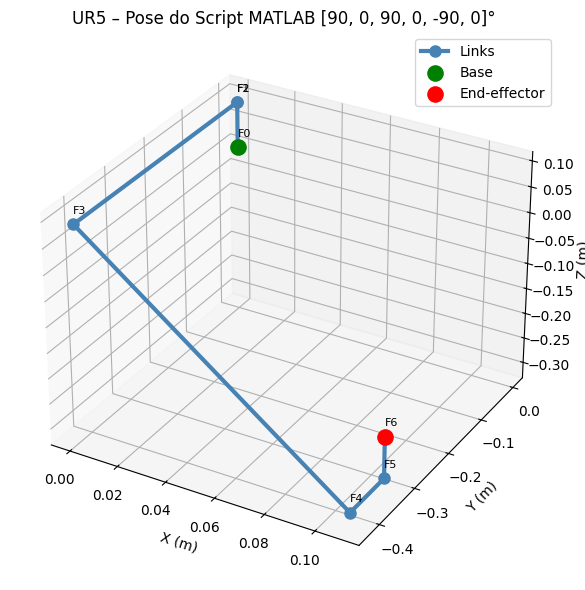

In [13]:
def plot_robot(thetas_deg, title='UR5 – Cadeia Cinemática'):
    """Plota o robô no espaço 3D a partir dos ângulos de junta."""
    _, chain = fk(thetas_deg)
    positions = np.array([T[:3, 3] for T in chain])  # (7, 3)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Links
    ax.plot(positions[:, 0], positions[:, 1], positions[:, 2],
            'o-', color='steelblue', linewidth=3, markersize=8, label='Links')

    # Destaca base e end-effector
    ax.scatter(*positions[0],  color='green',  s=120, zorder=5, label='Base')
    ax.scatter(*positions[-1], color='red',    s=120, zorder=5, label='End-effector')

    # Labels dos frames
    for i, pos in enumerate(positions):
        ax.text(pos[0], pos[1], pos[2]+0.02, f'F{i}', fontsize=8, color='black')

    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Plota a pose do script MATLAB
plot_robot([90, 0, 90, 0, -90, 0], title='UR5 – Pose do Script MATLAB [90, 0, 90, 0, -90, 0]°')

# Descomente para ver outra pose:
# plot_robot([30, -45, 60, 0, 90, 0], title='Pose Arbitrária')

---
## 9. Desconectar do CoppeliaSim

In [14]:
sim.simxAddStatusbarMessage(clientID, 'Python desconectado', sim.simx_opmode_oneshot)
import time; time.sleep(0.1)
sim.simxFinish(-1)
print("Desconectado do CoppeliaSim ✅")

Desconectado do CoppeliaSim ✅


---
## 📋 Checklist de problemas comuns

| Sintoma | Causa provável | Solução |
|---|---|---|
| `ModuleNotFoundError: No module named 'sim'` | Falta `sim.py` na pasta | Copie de `<CoppeliaSim>/programming/remoteApiBindings/python/python/` |
| `ConnectionError: ❌ Não foi possível conectar` | Simulador não está em Play | Abra `UR5.ttt` e pressione ▶ |
| Handles retornam `-1` | Nome de objeto diferente na cena | No CoppeliaSim, clique no objeto e veja o nome na barra lateral |
| Erros de posição > 1 cm | Convenção de Euler diferente | CoppeliaSim usa Euler ZYZ ou XYZ; ajuste a função `rotation_to_rpy` |
| `OSError: ... remoteApi` | Biblioteca não encontrada | Coloque `remoteApi.dll/.dylib/.so` na mesma pasta |
